In [2]:
from pathlib import Path

DANE = Path("Data")
if not DANE.exists():
    DANE = Path("../Data")

In [3]:
!wget -p {DANE} https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip

--2026-07-01 17:34:29--  http://../Data
Translacja .. (..)... nieudane: Ta nazwa lub usługa jest nieznana.
wget: nie udało się rozwiązać adresu hosta ‘..’
--2026-07-01 17:34:29--  https://github.com/olafbar/credo_files/raw/refs/heads/main/images_4class.zip
Translacja github.com (github.com)... 140.82.121.3
Łączenie się z github.com (github.com)|140.82.121.3|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 302 Found
Lokalizacja: https://raw.githubusercontent.com/olafbar/credo_files/refs/heads/main/images_4class.zip [podążanie]
--2026-07-01 17:34:30--  https://raw.githubusercontent.com/olafbar/credo_files/refs/heads/main/images_4class.zip
Translacja raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Łączenie się z raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... połączono.
Żądanie HTTP wysłano, oczekiwanie na odpowiedź... 200 OK
Długość: 5757268 (5,5M) [application/zip]
Zapis do:

In [ ]:
! unzip  images_4class.zip

Archive:  images_4class.zip
   creating: images/
   creating: images/artefacts/
 extracting: images/artefacts/10219929.png  
 extracting: images/artefacts/10219931.png  
 extracting: images/artefacts/10223942.png  
 extracting: images/artefacts/10228003.png  
 extracting: images/artefacts/10231268.png  
 extracting: images/artefacts/10231560.png  
 extracting: images/artefacts/10232861.png  
 extracting: images/artefacts/10233802.png  
 extracting: images/artefacts/10235049.png  
 extracting: images/artefacts/10235948.png  
 extracting: images/artefacts/10245995.png  
 extracting: images/artefacts/10259097.png  
 extracting: images/artefacts/1423633.png  
  inflating: images/artefacts/1423831.png  
 extracting: images/artefacts/1423932.png  
 extracting: images/artefacts/1424898.png  
 extracting: images/artefacts/1425966.png  
 extracting: images/artefacts/1426183.png  
 extracting: images/artefacts/1428338.png  
 extracting: images/artefacts/1428689.png  
 extracting: images/artefact

In [ ]:
!ls -l images

total 84
drwx------ 2 root root 36864 Jan 13  2021 artefacts
drwx------ 2 root root 20480 Dec 10  2020 dots
drwx------ 2 root root 12288 Dec 10  2020 lines
drwx------ 2 root root 12288 Dec 10  2020 worms


W plikach dostępne są rysunki o ujednoliconym rozmiarze. Są to wyniki rzeczywistego eksperymentu. Pochodzą z kamer telefonów komórkowych, które są zaklejone w związku z tym rejestrowane obrazy pochodzą z niemal z pewnością z promieniowania jonizującego w atmosferze.

Dane pochodzą z eksperymentu CREDO (www.credo.science)
Wstępna  obserwacja pozwala stwierdzić że dominujące obrazy można podzielić na cztery grupy :

1. Artefakty ( prawdopodobnie pochodzące z błędów kamery lub źle zasłoniętej soczewki)

2. linie (lines) ( prawdopodobnie pochodzący od cząstki przelatującej niemal w płaszczyźnie detektora )

3. kropki (dots) ( prawdopodobnie pochodzące od cząstki przelatującej prostopadle do płaszczyzny detektora)

4. robaki (worms) ( prawdopodobnie pochodzące od cząstki o niskiej energii która hamuje w detektorze)

Celem zadania jest stworzenie optymalnego klasyfikatora KNN

Etykiety w tym zbiorze są wynikiem głosowania wśród 5 niezależnych ekspertów którzy arbitralnie stwierdzali, do której klasy według ich subiektywnego odczucia przynależy dana detekcja. Uzgodnienie do której klasy należy detekcja następowało w przypadku zgodności co najmniej czterech z pięciu ekspertów.

Poniższe dane przedstawiają wyniki przykładowego klasyfikatora
KNN po bardzo pobieżnie przeprowadzonym procesie czyszczenia danych

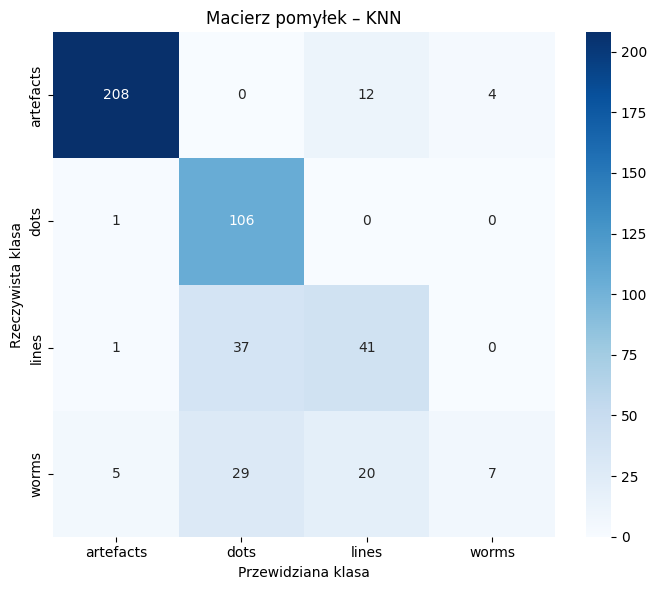

W przypadku gdyby zawiodły wszystkie standardowe ( w znaczeniu używane na ćwiczeniach lub omówione na wykładzie) metody można spróbować opracować metodę odrzucenia artefaktów i badania jedynie trzech klas lub w skrajnym przypadku odrzucenie artefaktów i kropek i skupienie się na badaniu jedynie dwóch klas (worms i lines)

Dopuszczalne jest również używanie wszystkich innych metod ale warunkiem koniecznym jest ich rozumienie i wyjaśnienie w odpowiedzi ustnej.

Szukam danych w: /content/images
Wczytywanie klasy: Artefacts...
 -> Załadowano 1122 obrazów.
Wczytywanie klasy: Dots...
 -> Załadowano 535 obrazów.
Wczytywanie klasy: Lines...
 -> Załadowano 393 obrazów.
Wczytywanie klasy: Worms...
 -> Załadowano 304 obrazów.

Zbiór treningowy: 1883, Zbiór testowy: 471

Rozpoczynam poszukiwanie optymalnych parametrów (GridSearch)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.82688498 0.82688498 0.81678283 0.82527936 0.80561967 0.81358711
 0.79606919 0.80137987 0.78066906 0.79288476 0.77004346 0.77960382
        nan 0.81997714        nan 0.82686382        nan 0.8077431
        nan 0.80190756        nan 0.78703934        nan 0.77534285]
  warnings.warn(



Najlepsze parametry: {'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Najlepsza dokładność (Cross-Validation): 82.69%

--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

   Artefacts       0.94      0.92      0.93       224
        Dots       0.84      0.96      0.90       107
       Lines       0.67      0.62      0.64        79
       Worms       0.52      0.46      0.49        61

    accuracy                           0.82       471
   macro avg       0.74      0.74      0.74       471
weighted avg       0.82      0.82      0.82       471



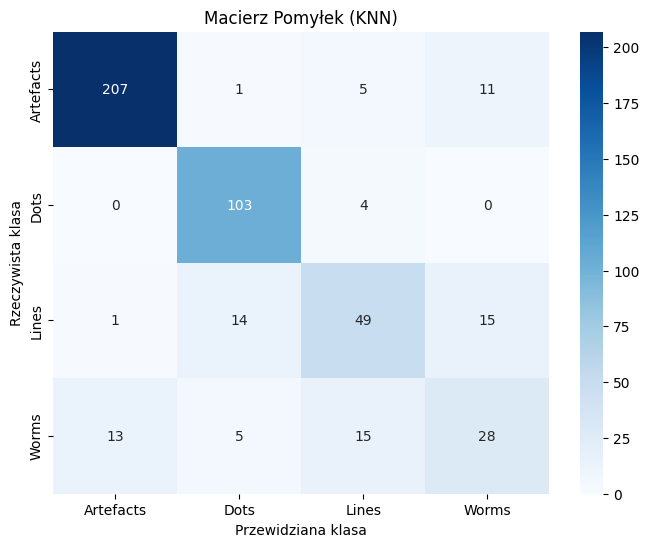

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# --- KONFIGURACJA ---
DATA_DIR = 'images'  # Zgodnie z Twoim poleceniem ls
IMG_SIZE = (64, 64)  # Ujednolicony rozmiar (optymalny kompromis jakość/szybkość)

# Mapowanie nazw folderów na etykiety
CLASS_MAP = {
    'artefacts': 'Artefacts',
    'dots': 'Dots',
    'lines': 'Lines',
    'worms': 'Worms'
}

def load_data(base_path):
    X = []
    y = []
    print(f"Szukam danych w: {os.path.abspath(base_path)}")

    for folder_name, label in CLASS_MAP.items():
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Ostrzeżenie: Nie znaleziono folderu {folder_path}")
            continue

        print(f"Wczytywanie klasy: {label}...")
        count = 0
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            # Wczytanie w skali szarości
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # Zmiana rozmiaru i spłaszczenie
                img = cv2.resize(img, IMG_SIZE)
                X.append(img.flatten())
                y.append(label)
                count += 1
        print(f" -> Załadowano {count} obrazów.")

    return np.array(X), np.array(y)

# 1. WCZYTANIE DANYCH
X, y = load_data(DATA_DIR)

if len(X) == 0:
    print("BŁĄD: Nie załadowano żadnych zdjęć. Sprawdź ścieżkę.")
else:
    # 2. PODZIAŁ NA TRENINGOWY I TESTOWY
    # stratify=y jest kluczowe przy nierównych klasach (np. mało worms)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nZbiór treningowy: {X_train.shape[0]}, Zbiór testowy: {X_test.shape[0]}")

    # 3. BUDOWA POTOKU (PIPELINE)
    # Pipeline łączy: Skalowanie -> PCA (opcjonalnie) -> KNN
    # Dzięki temu unikamy wycieku danych (data leakage) przy walidacji krzyżowej
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)), # Zachowaj 95% wariancji (usuń szum)
        ('knn', KNeighborsClassifier())
    ])

    # 4. SIATKA PARAMETRÓW DO PRZETESTOWANIA
    param_grid = {
        'knn__n_neighbors': [1, 3, 5, 7, 9, 11],   # Nieparzyste k
        'knn__weights': ['uniform', 'distance'],   # Czy brać pod uwagę odległość?
        'knn__metric': ['euclidean', 'manhattan']  # Manhattan często lepszy dla rzadkich danych
    }

    print("\nRozpoczynam poszukiwanie optymalnych parametrów (GridSearch)...")
    grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    # 5. WYNIKI
    print(f"\nNajlepsze parametry: {grid.best_params_}")
    print(f"Najlepsza dokładność (Cross-Validation): {grid.best_score_:.2%}")

    # Ewaluacja
    y_pred = grid.predict(X_test)

    print("\n--- RAPORT KLASYFIKACJI ---")
    print(classification_report(y_test, y_pred))

    # Wizualizacja Macierzy Pomyłek
    cm = confusion_matrix(y_test, y_pred, labels=list(CLASS_MAP.values()))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(CLASS_MAP.values()),
                yticklabels=list(CLASS_MAP.values()))
    plt.ylabel('Rzeczywista klasa')
    plt.xlabel('Przewidziana klasa')
    plt.title('Macierz Pomyłek (KNN)')
    plt.show()

## Wnioski

1.  Model osiągnął dokładność na zbiorze testowym **82%**. Najlepsze parametry dla modelu KNN to `k=1`, waga `uniform` i metryka `euclidean`.

2.  **Klasy o wysokiej skuteczności:**
    * Klasa "Artefacts" jest klasyfikowana z  wysoką precyzją (0.94) i czułością (0.92), co skutkuje wysokim wynikiem F1-score. Sugeruje to, że model bardzo dobrze radzi sobie z odróżnianiem artefaktów od innych klas.
    *   **Dots (Kropki):** Podobnie, klasa "Dots" również jest dobrze rozpoznawana, z wysoką czułością (0.96) i precyzją (0.84), co daje F1-score na poziomie 0.90. Model skutecznie identyfikuje większość "kropek".

3.  **Klasy o niższej skuteczności:**
    *   **Lines (Linie):** Klasyfikacja "Lines" jest umiarkowanie skuteczna, z precyzją 0.67 i czułością 0.62 (F1-score 0.64). Oznacza to, że znaczna część obrazów "Lines" jest błędnie klasyfikowana, a model ma trudności z ich jednoznacznym odróżnieniem od pozostałych kategorii.
    *   **Worms (Robaki):** Klasa "Worms" jest najtrudniejsza do poprawnej klasyfikacji dla obecnego modelu. Zarówno precyzja (0.52), jak i czułość (0.46) są niskie, co przekłada się na F1-score 0.49. To wskazuje, że model często myli "Worms" z innymi klasami i/lub nie jest w stanie poprawnie zidentyfikować połowy faktycznych "robaków".

4.  **Implikacje:** Niska skuteczność dla klas "Lines" i "Worms" może wynikać z ich większej subtelności wizualnej, mniejszej liczebności próbek (szczególnie "Worms" - 61 w zbiorze testowym vs 224 "Artefacts"), lub większego podobieństwa do innych klas (np. "Worms" do "Lines" lub nawet "Artefacts"). W kontekście opisu problemu, gdzie zasugerowano, że "Lines" i "Worms" są prawdopodobnie bardziej istotne dla eksperymentu (cząstki przelatujące), wyniki te wskazują na potrzebę dalszych ulepszeń. Możliwe rozwiązania to:
    *   **Augmentacja danych** dla klas "Lines" i "Worms" w celu zwiększenia ich liczebności.
    *   **Eksploracja innych cech** (feature extraction) niż tylko spłaszczony obraz.
    *   **Wypróbowanie innych algorytmów klasyfikacji**, które mogą lepiej radzić sobie z takimi danymi (np. sieci neuronowe).
    *   **Dalsza analiza wizualna** obrazów "Lines" i "Worms", aby lepiej zrozumieć, dlaczego model ma z nimi problemy.